# Семинар 2. Исследование методов линейной регрессии

#### Критерий оценивания:
#### Пункт 14: максимум 0,5 балла
#### Пункт 15: максимум 0,5 балла

#### Итого за работу: максимум 1 балл
#### P.S. пункты 14 и 15 без пунктов 1-13 не засчитываются, ответы на вопросы из ИИ не засчитываются

1. Загрузите датасет и выведите на экран первые несколько строк

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


data = pd.read_csv('data/auto_dataset.csv')
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


2. Разбейте выборку на признаки и ответы. Закодируйте категориальные признаки.

In [2]:
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(data, test_size=0.2, random_state=42)

df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

print(f"Размер обучающей выборки (train): {df_train.shape}")
print(f"Размер валидационной выборки (val): {df_val.shape}")
print(f"Размер тестовой выборки (test): {df_test.shape}")

Размер обучающей выборки (train): (800, 10)
Размер валидационной выборки (val): (100, 10)
Размер тестовой выборки (test): (100, 10)


3. Разбейте датасет на train val test в отношении 8:1:1

In [3]:
print("Train:")
display(df_train.head(2))

print("\nVal:")
display(df_val.head(2))

print("\nTest:")
display(df_test.head(2))

Train:


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
29,audi,a8,limousine,automatik,diesel,ja,232,150000,145,7499
535,volkswagen,golf,limousine,manuell,benzin,nein,75,125000,248,1099



Val:


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
411,volkswagen,golf,limousine,automatik,diesel,nein,104,150000,112,7800
621,renault,clio,kleinwagen,manuell,benzin,nein,75,125000,163,1690



Test:


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
436,renault,clio,kleinwagen,manuell,benzin,nein,58,90000,196,1800
899,audi,a8,limousine,automatik,diesel,nein,232,125000,88,18000


In [4]:
X_train = df_train.drop('price', axis=1).copy()
y_train = df_train['price'].values

X_val = df_val.drop('price', axis=1).copy()
y_val = df_val['price'].values

X_test = df_test.drop('price', axis=1).copy()
y_test = df_test['price'].values

In [5]:
# Средняя цена бренда/модели БЕЗ утечки.
# На train для каждой машины берём среднее по другим машинам той же категории.
# Val/test получают средние только из train — их цены туда не входят.

global_mean = y_train.mean()

for col in ['brand', 'model']:
    stats = df_train.groupby(col)['price'].agg(['sum', 'count'])
    n = df_train[col].map(stats['count'])  # сколько таких брендов/моделей в train
    s = df_train[col].map(stats['sum'])    # сумма их цен

    # (сумма - цена этой машины) / (количество - 1)
    # если модель в train одна — не подставляем её цену, а общее среднее
    n_others = n - 1
    X_train[col] = np.where(n_others > 0, (s - y_train) / n_others, global_mean)

    means = df_train.groupby(col)['price'].mean()
    X_val[col] = X_val[col].map(means).fillna(global_mean)
    X_test[col] = X_test[col].map(means).fillna(global_mean)


In [6]:
ohe_cols = ['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']
X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=True)
X_val = pd.get_dummies(X_val, columns=ohe_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=ohe_cols, drop_first=True)

In [7]:
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train, X_val, X_test = X_train.astype(float), X_val.astype(float), X_test.astype(float)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Добавляем столбец единиц (bias, w0) для матричных вычислений
X_train_scaled = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_val_scaled = np.c_[np.ones(X_val_scaled.shape[0]), X_val_scaled]
X_test_scaled = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

print(f"Форма X_train после кодирования: {X_train_scaled.shape}")
X_train

Форма X_train после кодирования: (800, 19)


,brand,model,powerPS,kilometer,autoAgeMonths,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,vehicleType_kleinwagen,vehicleType_kombi,vehicleType_limousine,vehicleType_suv,gearbox_manuell,fuelType_benzin,fuelType_diesel,fuelType_hybrid,fuelType_lpg,notRepairedDamage_nein
29,11062.298701,10400.000000,232.0,150000.0,145.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,5932.433735,4743.128571,75.0,125000.0,248.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
695,5999.946429,4055.750000,101.0,40000.0,17.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
557,8836.134831,6768.920000,163.0,100000.0,190.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
836,5901.710843,4670.271429,122.0,150000.0,96.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,5782.089286,19225.000000,305.0,90000.0,569.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
270,3799.333333,8730.950820,80.0,150000.0,287.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
860,5929.415663,4735.971429,90.0,150000.0,248.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
435,5628.454545,4826.000000,68.0,100000.0,78.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


4. Исследуйте VGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

VGD, постоянный шаг n (лучший — мин. Loss_val):

n=1e-05     Loss_train=86434549.32  R2_train=-0.4202  Loss_val=79697535.48
n=0.0001    Loss_train=27253721.48  R2_train=0.5522  Loss_val=21240523.30
n=0.001     Loss_train=18281334.75  R2_train=0.6996  Loss_val=20981175.98
n=0.01      Loss_train=18277312.98  R2_train=0.6997  Loss_val=21244090.48
n=0.1       Loss_train=18276988.78  R2_train=0.6997  Loss_val=21643603.15
n=1         Loss_train=inf  R2_train=-inf  Loss_val=inf

=> лучший шаг: 0.001


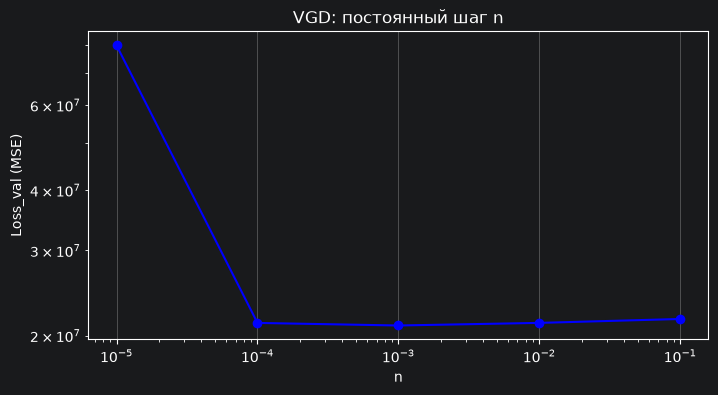

Loss_test: 26344611.17
R^2_test: 0.6222
Число итераций: 5000


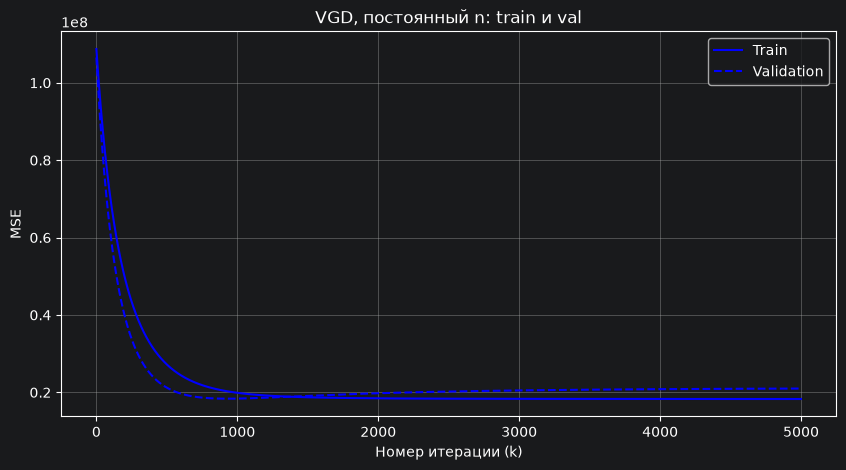

In [10]:
from sklearn.metrics import r2_score

# Те же вспомогательные функции, что в домашке.
# Разница семинара: шаг бывает постоянным (n) или затухающим TimeDecayLR (lambda).

def mse(y_true, y_pred):
    """MSE. Если веса взорвались — inf."""
    y_pred = np.asarray(y_pred, dtype=float)
    if not np.isfinite(y_pred).all():
        return np.inf
    with np.errstate(over="ignore", invalid="ignore"):
        err = np.mean((y_true - y_pred) ** 2)
    if not np.isfinite(err) or err > 1e20:
        return np.inf
    return err


def r2(y_true, y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    if not np.isfinite(y_pred).all():
        return -np.inf
    return r2_score(y_true, y_pred)


# Сетка из задания: 10^-5 ... 1
GRID = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]
N_ITER = 5000
S0, P = 1, 0.5  # параметры TimeDecayLR из лекции


def eta(step, k, decay):
    """decay=False: постоянный шаг n.
    decay=True: n(k) = lambda * (s0 / (s0 + k))^p."""
    if decay:
        return step * ((S0 / (S0 + k)) ** P)
    return step


def vanilla_gd(X, y, step, n_iter=N_ITER, decay=False):
    l = len(y)
    w = np.zeros(X.shape[1])
    for k in range(n_iter):
        gradient = (2 / l) * X.T.dot(X.dot(w) - y)
        w = w - eta(step, k, decay) * gradient
        if not np.isfinite(w).all():
            break
    return w


def vanilla_gd_history(X_train, y_train, X_val, y_val, step, n_iter=N_ITER, decay=False):
    l = len(y_train)
    w = np.zeros(X_train.shape[1])
    train_hist, val_hist = [], []
    for k in range(n_iter):
        gradient = (2 / l) * X_train.T.dot(X_train.dot(w) - y_train)
        w = w - eta(step, k, decay) * gradient
        train_hist.append(mse(y_train, X_train.dot(w)))
        val_hist.append(mse(y_val, X_val.dot(w)))
        if not np.isfinite(w).all():
            break
    return w, train_hist, val_hist


def search_step(fit_fn, decay, title):
    """Перебор GRID, лучший шаг — минимальный Loss_val. Test не трогаем."""
    curve = {}
    best_step, best_val = None, np.inf
    best_stats = None
    print(f"{title}\n")
    for step in GRID:
        w = fit_fn(X_train_scaled, y_train, step, n_iter=N_ITER, decay=decay)
        y_tr = X_train_scaled.dot(w)
        y_v = X_val_scaled.dot(w)
        loss_tr, r2_tr = mse(y_train, y_tr), r2(y_train, y_tr)
        loss_v = mse(y_val, y_v)
        curve[step] = loss_v
        name = "lambda" if decay else "n"
        print(f"{name}={step:<8}  Loss_train={loss_tr:.2f}  R2_train={r2_tr:.4f}  Loss_val={loss_v:.2f}")
        if np.isfinite(loss_v) and loss_v < best_val:
            best_val = loss_v
            best_step = step
            best_stats = (loss_tr, r2_tr, loss_v)
    print(f"\n=> лучший шаг: {best_step}")
    return best_step, best_stats, curve


def plot_curve(curve, xlabel, title, color):
    xs = [s for s, loss in curve.items() if np.isfinite(loss)]
    ys = [curve[s] for s in xs]
    plt.figure(figsize=(8, 4))
    plt.plot(xs, ys, marker="o", color=color)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(xlabel)
    plt.ylabel("Loss_val (MSE)")
    plt.title(title)
    plt.grid(True)
    plt.show()


def plot_hist(train_h, val_h, title, color):
    plt.figure(figsize=(10, 5))
    plt.plot(train_h, label="Train", color=color)
    plt.plot(val_h, label="Validation", color=color, linestyle="--")
    plt.title(title)
    plt.xlabel("Номер итерации (k)")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.legend()
    plt.show()


def finish(fit_hist, best_step, decay, title, color):
    """Обучение с лучшим шагом, метрики на test, график train/val."""
    w, tr_h, va_h = fit_hist(
        X_train_scaled, y_train, X_val_scaled, y_val,
        best_step, n_iter=N_ITER, decay=decay,
    )
    y_tr = X_train_scaled.dot(w)
    y_te = X_test_scaled.dot(w)
    stats = {
        "loss_train": mse(y_train, y_tr),
        "r2_train": r2(y_train, y_tr),
        "loss_test": mse(y_test, y_te),
        "r2_test": r2(y_test, y_te),
        "n_iter": N_ITER,
        "hist_tr": tr_h,
        "hist_val": va_h,
    }
    print(f"Loss_test: {stats['loss_test']:.2f}")
    print(f"R^2_test: {stats['r2_test']:.4f}")
    print(f"Число итераций: {N_ITER}")
    plot_hist(tr_h, va_h, title, color)
    return stats


sem_rows = []  # сюда складываем строки итоговой таблицы

# 4. VGD с постоянным шагом n
best_n_vgd, stats_n_vgd, curve_n_vgd = search_step(
    vanilla_gd, decay=False, title="VGD, постоянный шаг n (лучший — мин. Loss_val):"
)
plot_curve(curve_n_vgd, "n", "VGD: постоянный шаг n", "blue")
vgd_n = finish(vanilla_gd_history, best_n_vgd, False, "VGD, постоянный n: train и val", "blue")
sem_rows.append({
    "Метод": "Vanilla GD, постоянный n",
    "Шаг": f"n = {best_n_vgd:g}",
    "Loss train": vgd_n["loss_train"],
    "Loss test": vgd_n["loss_test"],
    "R2 train": vgd_n["r2_train"],
    "R2 test": vgd_n["r2_test"],
    "Итерации": N_ITER,
})


5. Исследуйте VGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

VGD, TimeDecayLR (лучший lambda — мин. Loss_val):

lambda=1e-05     Loss_train=108515446.32  R2_train=-0.7830  Loss_val=106277527.81
lambda=0.0001    Loss_train=102019130.10  R2_train=-0.6762  Loss_val=98338108.50
lambda=0.001     Loss_train=60754239.64  R2_train=0.0018  Loss_val=50890237.40
lambda=0.01      Loss_train=18838118.43  R2_train=0.6905  Loss_val=18939213.93
lambda=0.1       Loss_train=18278239.64  R2_train=0.6997  Loss_val=21155687.03
lambda=1         Loss_train=18277026.40  R2_train=0.6997  Loss_val=21405262.93

=> лучший шаг: 0.01


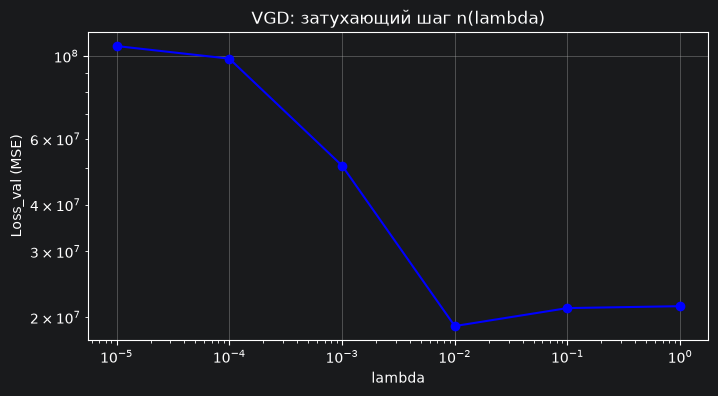

Loss_test: 27442498.59
R^2_test: 0.6065
Число итераций: 5000


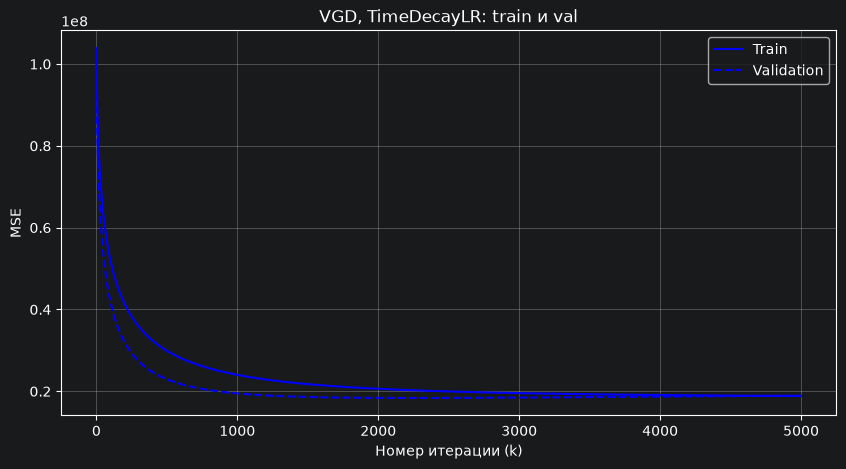

In [11]:
# 5. VGD с переменным шагом TimeDecayLR: n(k) = lambda * (s0/(s0+k))^p
best_lam_vgd, _, curve_lam_vgd = search_step(
    vanilla_gd, decay=True, title="VGD, TimeDecayLR (лучший lambda — мин. Loss_val):"
)
plot_curve(curve_lam_vgd, "lambda", "VGD: затухающий шаг n(lambda)", "blue")
vgd_d = finish(vanilla_gd_history, best_lam_vgd, True, "VGD, TimeDecayLR: train и val", "blue")
sem_rows.append({
    "Метод": "Vanilla GD, TimeDecayLR",
    "Шаг": f"n(k) = {best_lam_vgd:g} * (1/(1+k))^0.5",
    "Loss train": vgd_d["loss_train"],
    "Loss test": vgd_d["loss_test"],
    "R2 train": vgd_d["r2_train"],
    "R2 test": vgd_d["r2_test"],
    "Итерации": N_ITER,
})


6. Исследуйте SGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

SGD, постоянный шаг n (лучший — мин. Loss_val):

n=1e-05     Loss_train=86199279.74  R2_train=-0.4163  Loss_val=79358917.56
n=0.0001    Loss_train=27056485.93  R2_train=0.5554  Loss_val=21093317.17
n=0.001     Loss_train=18297986.45  R2_train=0.6994  Loss_val=21304190.63
n=0.01      Loss_train=18466233.50  R2_train=0.6966  Loss_val=22239438.40
n=0.1       Loss_train=inf  R2_train=-11857212751967684153682087643759833195271060889747279803657170559599705675454483700620601071979396627428711704895269673051181241230569712938956489740887807639793111128975728370282599431762766244589687433971088569833610918844872073760735232.0000  Loss_val=inf
n=1         Loss_train=inf  R2_train=-inf  Loss_val=inf

=> лучший шаг: 0.0001


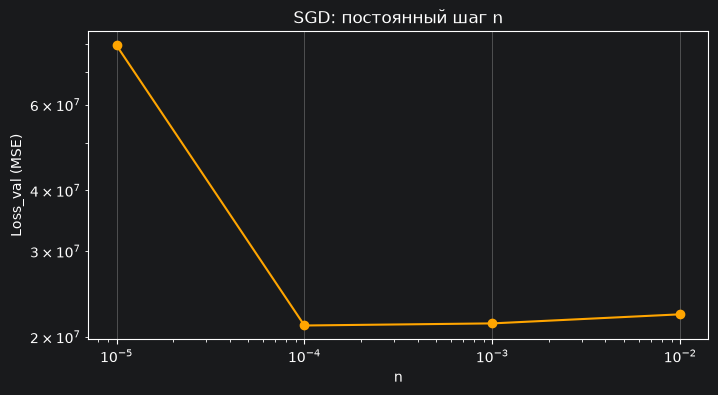

Loss_test: 34662645.23
R^2_test: 0.5030
Число итераций: 5000


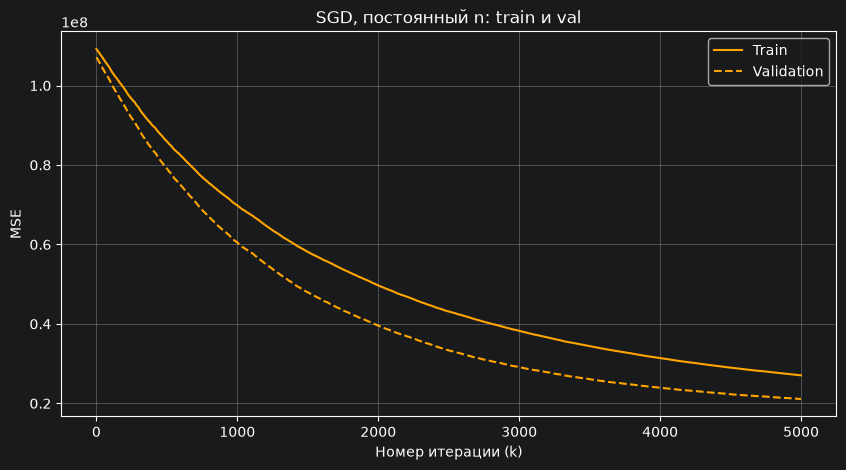

In [12]:
# SGD: градиент по случайному батчу, как в домашке.

def sgd_descent(X, y, step, n_iter=N_ITER, decay=False, batch_size=32, seed=42):
    np.random.seed(seed)
    n = len(y)
    w = np.zeros(X.shape[1])
    for k in range(n_iter):
        idx = np.random.choice(n, size=batch_size, replace=False)
        X_b, y_b = X[idx], y[idx]
        gradient = (2 / batch_size) * X_b.T.dot(X_b.dot(w) - y_b)
        w = w - eta(step, k, decay) * gradient
        if not np.isfinite(w).all():
            break
    return w


def sgd_descent_history(X_train, y_train, X_val, y_val, step, n_iter=N_ITER, decay=False,
                        batch_size=32, seed=42):
    np.random.seed(seed)
    n = len(y_train)
    w = np.zeros(X_train.shape[1])
    train_hist, val_hist = [], []
    for k in range(n_iter):
        idx = np.random.choice(n, size=batch_size, replace=False)
        X_b, y_b = X_train[idx], y_train[idx]
        gradient = (2 / batch_size) * X_b.T.dot(X_b.dot(w) - y_b)
        w = w - eta(step, k, decay) * gradient
        train_hist.append(mse(y_train, X_train.dot(w)))
        val_hist.append(mse(y_val, X_val.dot(w)))
        if not np.isfinite(w).all():
            break
    return w, train_hist, val_hist


# 6. SGD с постоянным шагом n
best_n_sgd, _, curve_n_sgd = search_step(
    sgd_descent, decay=False, title="SGD, постоянный шаг n (лучший — мин. Loss_val):"
)
plot_curve(curve_n_sgd, "n", "SGD: постоянный шаг n", "orange")
sgd_n = finish(sgd_descent_history, best_n_sgd, False, "SGD, постоянный n: train и val", "orange")
sem_rows.append({
    "Метод": "SGD, постоянный n",
    "Шаг": f"n = {best_n_sgd:g}",
    "Loss train": sgd_n["loss_train"],
    "Loss test": sgd_n["loss_test"],
    "R2 train": sgd_n["r2_train"],
    "R2 test": sgd_n["r2_test"],
    "Итерации": N_ITER,
})


7. Исследуйте SGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

SGD, TimeDecayLR (лучший lambda — мин. Loss_val):

lambda=1e-05     Loss_train=108506862.55  R2_train=-0.7828  Loss_val=106266751.42
lambda=0.0001    Loss_train=101939048.64  R2_train=-0.6749  Loss_val=98238083.15
lambda=0.001     Loss_train=60352182.78  R2_train=0.0084  Loss_val=50422301.00
lambda=0.01      Loss_train=18781921.45  R2_train=0.6914  Loss_val=19156238.29
lambda=0.1       Loss_train=18306693.99  R2_train=0.6992  Loss_val=21558776.48
lambda=1         Loss_train=13683071147781.45  R2_train=-224818.7003  Loss_val=4926713240546124.00

=> лучший шаг: 0.01


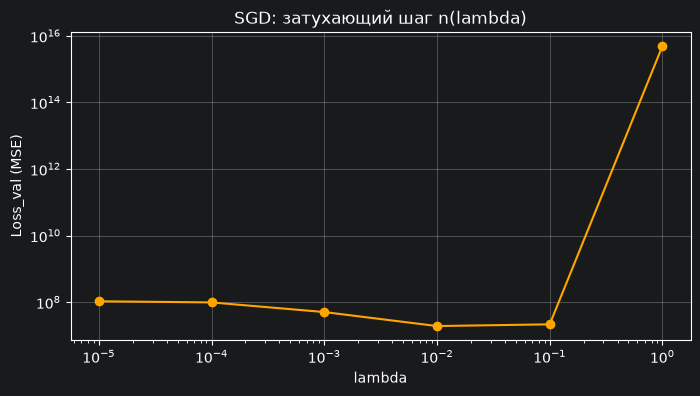

Loss_test: 27321098.81
R^2_test: 0.6082
Число итераций: 5000


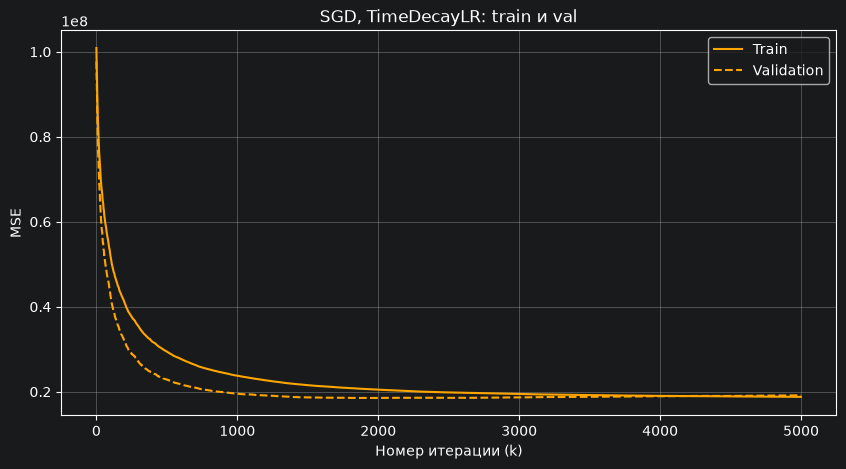

In [13]:
# 7. SGD с переменным шагом TimeDecayLR
best_lam_sgd, _, curve_lam_sgd = search_step(
    sgd_descent, decay=True, title="SGD, TimeDecayLR (лучший lambda — мин. Loss_val):"
)
plot_curve(curve_lam_sgd, "lambda", "SGD: затухающий шаг n(lambda)", "orange")
sgd_d = finish(sgd_descent_history, best_lam_sgd, True, "SGD, TimeDecayLR: train и val", "orange")
sem_rows.append({
    "Метод": "SGD, TimeDecayLR",
    "Шаг": f"n(k) = {best_lam_sgd:g} * (1/(1+k))^0.5",
    "Loss train": sgd_d["loss_train"],
    "Loss test": sgd_d["loss_test"],
    "R2 train": sgd_d["r2_train"],
    "R2 test": sgd_d["r2_test"],
    "Итерации": N_ITER,
})


8. Исследуйте SAG с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

SAG, постоянный шаг n (лучший — мин. Loss_val):

n=1e-05     Loss_train=89504549.11  R2_train=-0.4706  Loss_val=83372063.37
n=0.0001    Loss_train=27811106.84  R2_train=0.5430  Loss_val=20893212.03
n=0.001     Loss_train=18416344.86  R2_train=0.6974  Loss_val=20882820.03
n=0.01      Loss_train=154144236168.90  R2_train=-2531.6669  Loss_val=525985632.13
n=0.1       Loss_train=inf  R2_train=-5156162726285.7676  Loss_val=1236025630353206272.00
n=1         Loss_train=inf  R2_train=-176359854872477109845442066243503715398619997469701638630947413280838462788061038907306338958800372136673280.0000  Loss_val=inf

=> лучший шаг: 0.001


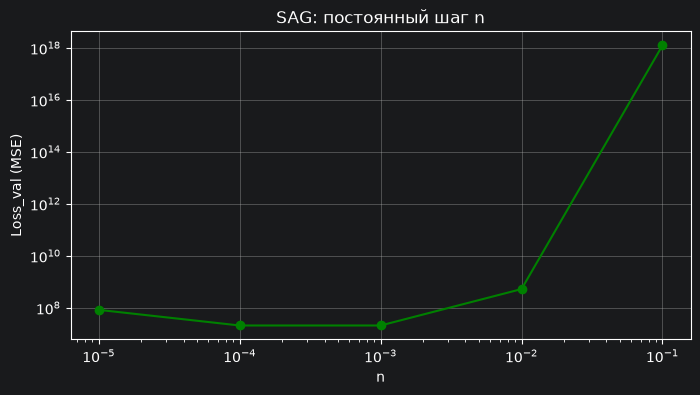

Loss_test: 25847428.88
R^2_test: 0.6294
Число итераций: 5000


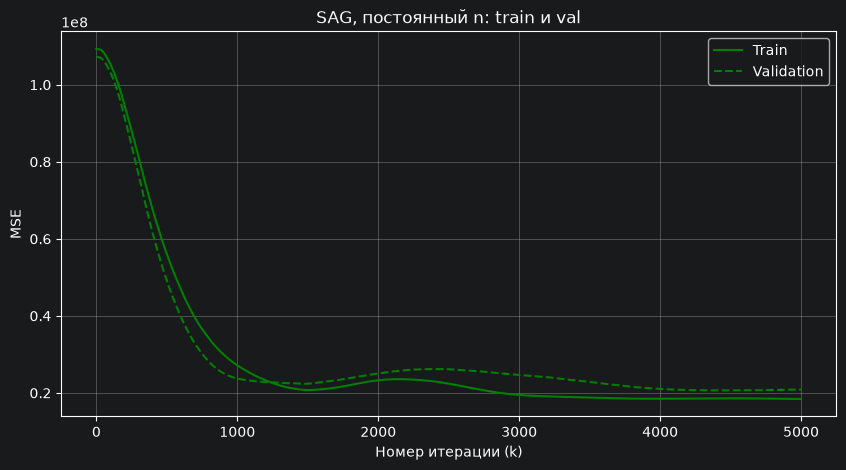

In [14]:
# SAG: храним градиент каждого объекта, спускаемся по среднему.

def sag_descent(X, y, step, n_iter=N_ITER, decay=False, seed=42):
    np.random.seed(seed)
    n, d = X.shape
    w = np.zeros(d)
    grads = np.zeros((n, d))
    g_bar = np.zeros(d)
    for k in range(n_iter):
        j = np.random.randint(n)
        g_new = 2.0 * (X[j].dot(w) - y[j]) * X[j]
        g_bar = g_bar + (g_new - grads[j]) / n
        grads[j] = g_new
        w = w - eta(step, k, decay) * g_bar
        if not np.isfinite(w).all():
            break
    return w


def sag_descent_history(X_train, y_train, X_val, y_val, step, n_iter=N_ITER, decay=False, seed=42):
    np.random.seed(seed)
    n, d = X_train.shape
    w = np.zeros(d)
    grads = np.zeros((n, d))
    g_bar = np.zeros(d)
    train_hist, val_hist = [], []
    for k in range(n_iter):
        j = np.random.randint(n)
        g_new = 2.0 * (X_train[j].dot(w) - y_train[j]) * X_train[j]
        g_bar = g_bar + (g_new - grads[j]) / n
        grads[j] = g_new
        w = w - eta(step, k, decay) * g_bar
        train_hist.append(mse(y_train, X_train.dot(w)))
        val_hist.append(mse(y_val, X_val.dot(w)))
        if not np.isfinite(w).all():
            break
    return w, train_hist, val_hist


# 8. SAG с постоянным шагом n
best_n_sag, _, curve_n_sag = search_step(
    sag_descent, decay=False, title="SAG, постоянный шаг n (лучший — мин. Loss_val):"
)
plot_curve(curve_n_sag, "n", "SAG: постоянный шаг n", "green")
sag_n = finish(sag_descent_history, best_n_sag, False, "SAG, постоянный n: train и val", "green")
sem_rows.append({
    "Метод": "SAG, постоянный n",
    "Шаг": f"n = {best_n_sag:g}",
    "Loss train": sag_n["loss_train"],
    "Loss test": sag_n["loss_test"],
    "R2 train": sag_n["r2_train"],
    "R2 test": sag_n["r2_test"],
    "Итерации": N_ITER,
})


9. Исследуйте SAG с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

SAG, TimeDecayLR (лучший lambda — мин. Loss_val):

lambda=1e-05     Loss_train=108785127.20  R2_train=-0.7874  Loss_val=106617595.34
lambda=0.0001    Loss_train=104498961.08  R2_train=-0.7170  Loss_val=101438716.81
lambda=0.001     Loss_train=72151940.92  R2_train=-0.1855  Loss_val=63584636.60
lambda=0.01      Loss_train=19130013.73  R2_train=0.6857  Loss_val=18555144.53
lambda=0.1       Loss_train=18365225.14  R2_train=0.6983  Loss_val=20932772.77
lambda=1         Loss_train=14771074224026.15  R2_train=-242695.1348  Loss_val=46284564407.26

=> лучший шаг: 0.01


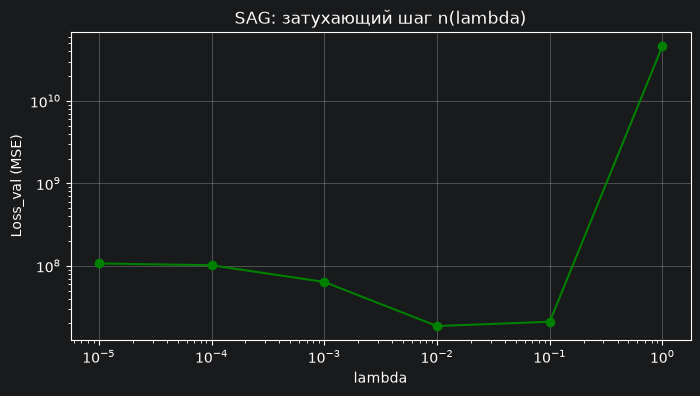

Loss_test: 27859749.31
R^2_test: 0.6005
Число итераций: 5000


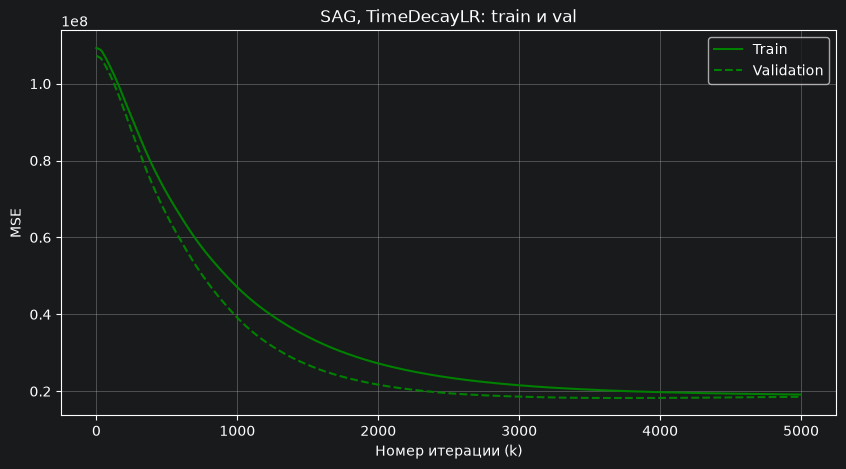

In [15]:
# 9. SAG с переменным шагом TimeDecayLR
best_lam_sag, _, curve_lam_sag = search_step(
    sag_descent, decay=True, title="SAG, TimeDecayLR (лучший lambda — мин. Loss_val):"
)
plot_curve(curve_lam_sag, "lambda", "SAG: затухающий шаг n(lambda)", "green")
sag_d = finish(sag_descent_history, best_lam_sag, True, "SAG, TimeDecayLR: train и val", "green")
sem_rows.append({
    "Метод": "SAG, TimeDecayLR",
    "Шаг": f"n(k) = {best_lam_sag:g} * (1/(1+k))^0.5",
    "Loss train": sag_d["loss_train"],
    "Loss test": sag_d["loss_test"],
    "R2 train": sag_d["r2_train"],
    "R2 test": sag_d["r2_test"],
    "Итерации": N_ITER,
})


10. Исследуйте Momentum с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

Momentum, постоянный шаг n (лучший — мин. Loss_val):

n=1e-05     Loss_train=27251015.32  R2_train=0.5523  Loss_val=21235547.45
n=0.0001    Loss_train=18281259.95  R2_train=0.6996  Loss_val=20983702.20
n=0.001     Loss_train=18277312.97  R2_train=0.6997  Loss_val=21243952.07
n=0.01      Loss_train=18276988.77  R2_train=0.6997  Loss_val=21643944.05
n=0.1       Loss_train=18276988.02  R2_train=0.6997  Loss_val=21687988.41
n=1         Loss_train=inf  R2_train=-inf  Loss_val=inf

=> лучший шаг: 0.0001


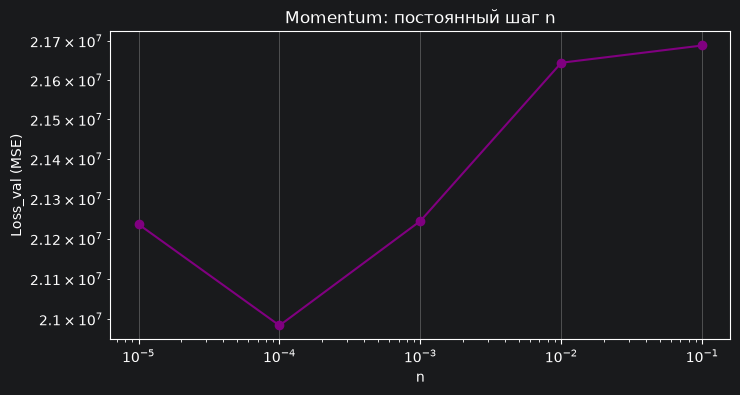

Loss_test: 26343059.16
R^2_test: 0.6223
Число итераций: 5000


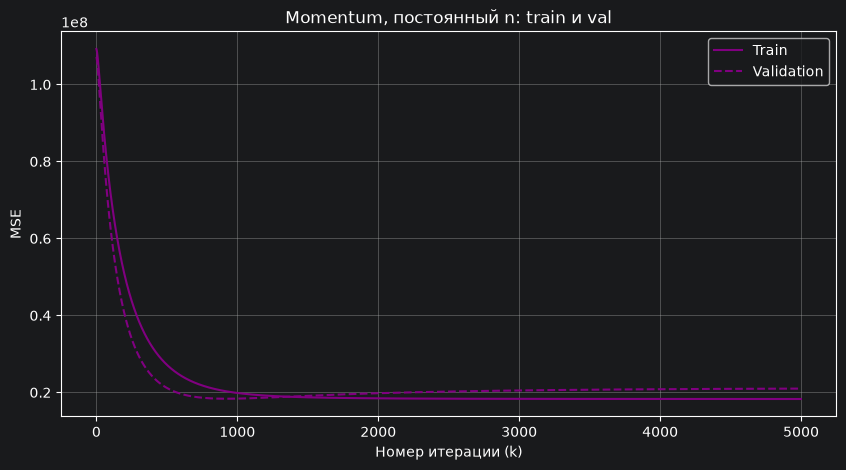

In [16]:
# Momentum: полный градиент + импульс alpha=0.9, как в домашке.

def momentum_descent(X, y, step, n_iter=N_ITER, decay=False, alpha=0.9):
    n = len(y)
    w = np.zeros(X.shape[1])
    h = np.zeros(X.shape[1])
    for k in range(n_iter):
        gradient = (2 / n) * X.T.dot(X.dot(w) - y)
        h = alpha * h + eta(step, k, decay) * gradient
        w = w - h
        if not np.isfinite(w).all():
            break
    return w


def momentum_descent_history(X_train, y_train, X_val, y_val, step, n_iter=N_ITER, decay=False, alpha=0.9):
    n = len(y_train)
    w = np.zeros(X_train.shape[1])
    h = np.zeros(X_train.shape[1])
    train_hist, val_hist = [], []
    for k in range(n_iter):
        gradient = (2 / n) * X_train.T.dot(X_train.dot(w) - y_train)
        h = alpha * h + eta(step, k, decay) * gradient
        w = w - h
        train_hist.append(mse(y_train, X_train.dot(w)))
        val_hist.append(mse(y_val, X_val.dot(w)))
        if not np.isfinite(w).all():
            break
    return w, train_hist, val_hist


# 10. Momentum с постоянным шагом n
best_n_mom, _, curve_n_mom = search_step(
    momentum_descent, decay=False, title="Momentum, постоянный шаг n (лучший — мин. Loss_val):"
)
plot_curve(curve_n_mom, "n", "Momentum: постоянный шаг n", "purple")
mom_n = finish(momentum_descent_history, best_n_mom, False, "Momentum, постоянный n: train и val", "purple")
sem_rows.append({
    "Метод": "Momentum, постоянный n",
    "Шаг": f"n = {best_n_mom:g}",
    "Loss train": mom_n["loss_train"],
    "Loss test": mom_n["loss_test"],
    "R2 train": mom_n["r2_train"],
    "R2 test": mom_n["r2_test"],
    "Итерации": N_ITER,
})


11. Исследуйте Momentum с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

Momentum, TimeDecayLR (лучший lambda — мин. Loss_val):

lambda=1e-05     Loss_train=102024184.04  R2_train=-0.6763  Loss_val=98344026.37
lambda=0.0001    Loss_train=60738009.21  R2_train=0.0020  Loss_val=50862914.85
lambda=0.001     Loss_train=18826649.94  R2_train=0.6907  Loss_val=18952062.83
lambda=0.01      Loss_train=18278239.57  R2_train=0.6997  Loss_val=21155753.57
lambda=0.1       Loss_train=18277026.04  R2_train=0.6997  Loss_val=21405608.47
lambda=1         Loss_train=18276988.02  R2_train=0.6997  Loss_val=21687670.46

=> лучший шаг: 0.001


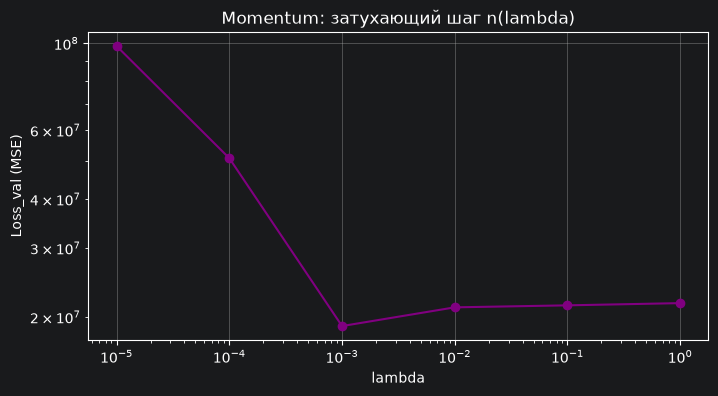

Loss_test: 27443197.80
R^2_test: 0.6065
Число итераций: 5000


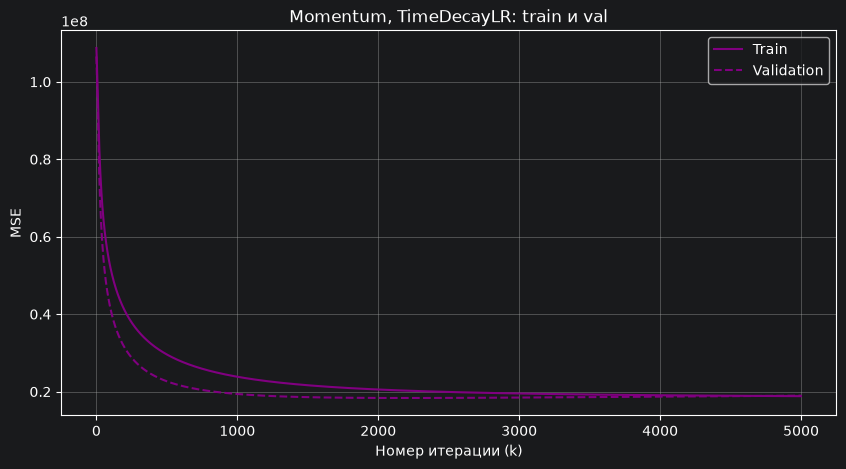

In [17]:
# 11. Momentum с переменным шагом TimeDecayLR
best_lam_mom, _, curve_lam_mom = search_step(
    momentum_descent, decay=True, title="Momentum, TimeDecayLR (лучший lambda — мин. Loss_val):"
)
plot_curve(curve_lam_mom, "lambda", "Momentum: затухающий шаг n(lambda)", "purple")
mom_d = finish(momentum_descent_history, best_lam_mom, True, "Momentum, TimeDecayLR: train и val", "purple")
sem_rows.append({
    "Метод": "Momentum, TimeDecayLR",
    "Шаг": f"n(k) = {best_lam_mom:g} * (1/(1+k))^0.5",
    "Loss train": mom_d["loss_train"],
    "Loss test": mom_d["loss_test"],
    "R2 train": mom_d["r2_train"],
    "R2 test": mom_d["r2_test"],
    "Итерации": N_ITER,
})


12. Исследуйте Adam с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

Adam, постоянный шаг n (лучший — мин. Loss_val):

n=1e-05     Loss_train=109272047.52  R2_train=-0.7954  Loss_val=107206795.51
n=0.0001    Loss_train=109237642.56  R2_train=-0.7948  Loss_val=107157463.76
n=0.001     Loss_train=108894613.63  R2_train=-0.7892  Loss_val=106666319.38
n=0.01      Loss_train=105560182.46  R2_train=-0.7344  Loss_val=102036254.29
n=0.1       Loss_train=80492551.68  R2_train=-0.3225  Loss_val=67544113.35
n=1         Loss_train=25316092.76  R2_train=0.5840  Loss_val=21641734.63

=> лучший шаг: 1


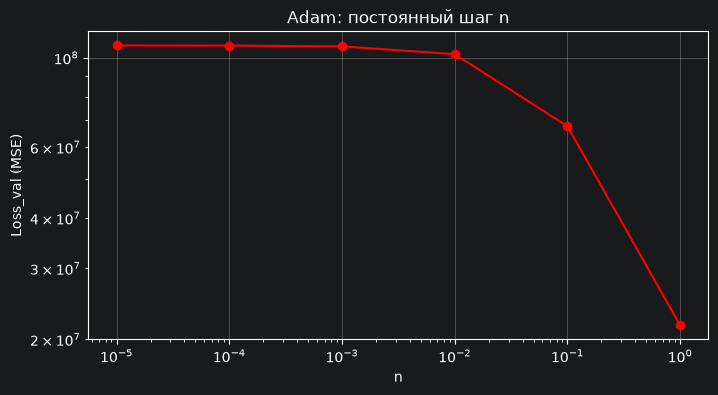

Loss_test: 30490395.41
R^2_test: 0.5628
Число итераций: 5000


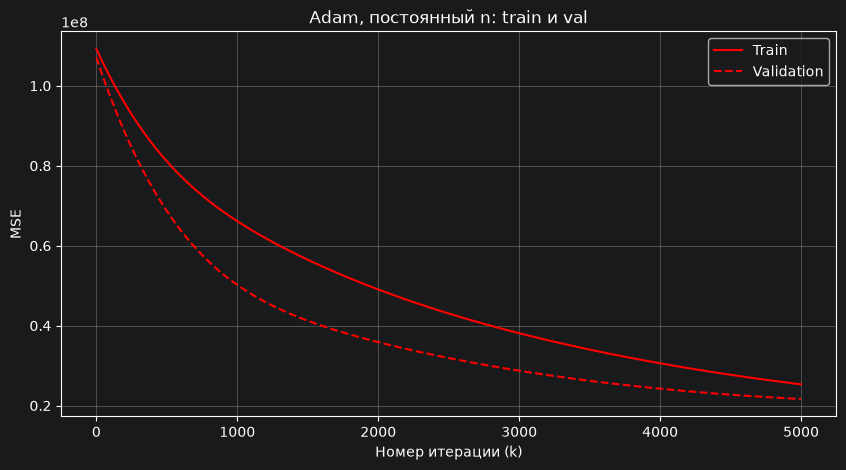

In [18]:
# Adam: адаптивный шаг, beta1=0.9, beta2=0.999, eps=1e-8.

def adam_descent(X, y, step, n_iter=N_ITER, decay=False, beta1=0.9, beta2=0.999, eps=1e-8):
    n = len(y)
    w = np.zeros(X.shape[1])
    m = np.zeros(X.shape[1])
    v = np.zeros(X.shape[1])
    for k in range(n_iter):
        g = (2 / n) * X.T.dot(X.dot(w) - y)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g ** 2)
        m_hat = m / (1 - beta1 ** (k + 1))
        v_hat = v / (1 - beta2 ** (k + 1))
        w = w - eta(step, k, decay) * m_hat / (np.sqrt(v_hat) + eps)
        if not np.isfinite(w).all():
            break
    return w


def adam_descent_history(X_train, y_train, X_val, y_val, step, n_iter=N_ITER, decay=False,
                         beta1=0.9, beta2=0.999, eps=1e-8):
    n = len(y_train)
    w = np.zeros(X_train.shape[1])
    m = np.zeros(X_train.shape[1])
    v = np.zeros(X_train.shape[1])
    train_hist, val_hist = [], []
    for k in range(n_iter):
        g = (2 / n) * X_train.T.dot(X_train.dot(w) - y_train)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g ** 2)
        m_hat = m / (1 - beta1 ** (k + 1))
        v_hat = v / (1 - beta2 ** (k + 1))
        w = w - eta(step, k, decay) * m_hat / (np.sqrt(v_hat) + eps)
        train_hist.append(mse(y_train, X_train.dot(w)))
        val_hist.append(mse(y_val, X_val.dot(w)))
        if not np.isfinite(w).all():
            break
    return w, train_hist, val_hist


# 12. Adam с постоянным шагом n
best_n_adam, _, curve_n_adam = search_step(
    adam_descent, decay=False, title="Adam, постоянный шаг n (лучший — мин. Loss_val):"
)
plot_curve(curve_n_adam, "n", "Adam: постоянный шаг n", "red")
adam_n = finish(adam_descent_history, best_n_adam, False, "Adam, постоянный n: train и val", "red")
sem_rows.append({
    "Метод": "Adam, постоянный n",
    "Шаг": f"n = {best_n_adam:g}",
    "Loss train": adam_n["loss_train"],
    "Loss test": adam_n["loss_test"],
    "R2 train": adam_n["r2_train"],
    "R2 test": adam_n["r2_test"],
    "Итерации": N_ITER,
})


13. Исследуйте Adam с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

Adam, TimeDecayLR (лучший lambda — мин. Loss_val):

lambda=1e-05     Loss_train=109275764.39  R2_train=-0.7955  Loss_val=107212125.59
lambda=0.0001    Loss_train=109274800.96  R2_train=-0.7954  Loss_val=107210744.00
lambda=0.001     Loss_train=109265167.43  R2_train=-0.7953  Loss_val=107196929.47
lambda=0.01      Loss_train=109168907.97  R2_train=-0.7937  Loss_val=107058923.63
lambda=0.1       Loss_train=108213811.25  R2_train=-0.7780  Loss_val=105698013.10
lambda=1         Loss_train=99345450.06  R2_train=-0.6323  Loss_val=93475085.13

=> лучший шаг: 1


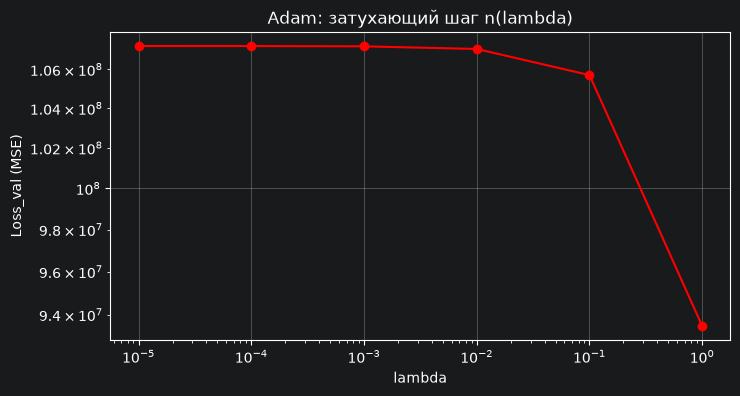

Loss_test: 116687113.61
R^2_test: -0.6732
Число итераций: 5000


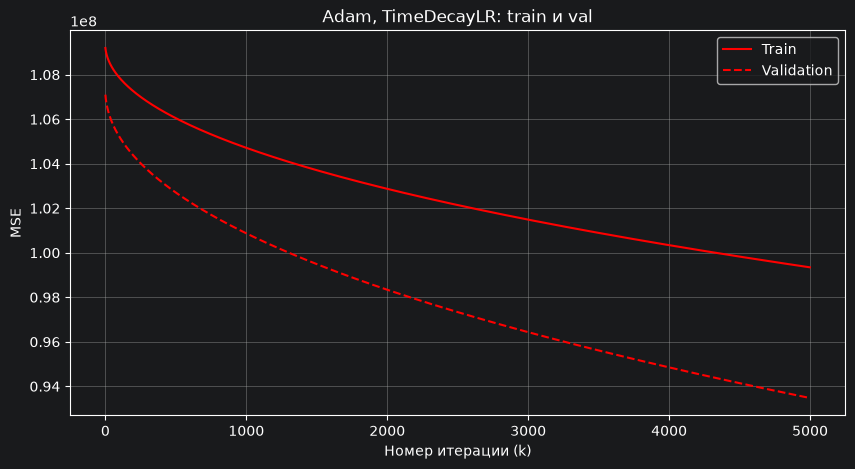

In [19]:
# 13. Adam с переменным шагом TimeDecayLR
best_lam_adam, _, curve_lam_adam = search_step(
    adam_descent, decay=True, title="Adam, TimeDecayLR (лучший lambda — мин. Loss_val):"
)
plot_curve(curve_lam_adam, "lambda", "Adam: затухающий шаг n(lambda)", "red")
adam_d = finish(adam_descent_history, best_lam_adam, True, "Adam, TimeDecayLR: train и val", "red")
sem_rows.append({
    "Метод": "Adam, TimeDecayLR",
    "Шаг": f"n(k) = {best_lam_adam:g} * (1/(1+k))^0.5",
    "Loss train": adam_d["loss_train"],
    "Loss test": adam_d["loss_test"],
    "R2 train": adam_d["r2_train"],
    "R2 test": adam_d["r2_test"],
    "Итерации": N_ITER,
})


14. Постройте итоговую сравнительную таблицу со следующими столбцами:

1) название метода

2) значение лучшего шага (если n) или функция лучшего шага (если n(lyamda))

3) Loss_train

4) Loss_test

5) R^2 train

6) R^2 test

7) число итераций на test

,Метод,Шаг,Loss train,Loss test,R2 train,R2 test,Итерации
0,"Vanilla GD, постоянный n",n = 0.001,18281334.75,26344611.17,0.6996,0.6222,5000
1,"Vanilla GD, TimeDecayLR",n(k) = 0.01 * (1/(1+k))^0.5,18838118.43,27442498.59,0.6905,0.6065,5000
2,"SGD, постоянный n",n = 0.0001,27056485.93,34662645.23,0.5554,0.5030,5000
3,"SGD, TimeDecayLR",n(k) = 0.01 * (1/(1+k))^0.5,18781921.45,27321098.81,0.6914,0.6082,5000
4,"SAG, постоянный n",n = 0.001,18416344.86,25847428.88,0.6974,0.6294,5000
5,"SAG, TimeDecayLR",n(k) = 0.01 * (1/(1+k))^0.5,19130013.73,27859749.31,0.6857,0.6005,5000
6,"Momentum, постоянный n",n = 0.0001,18281259.95,26343059.16,0.6996,0.6223,5000
7,"Momentum, TimeDecayLR",n(k) = 0.001 * (1/(1+k))^0.5,18826649.94,27443197.80,0.6907,0.6065,5000
8,"Adam, постоянный n",n = 1,25316092.76,30490395.41,0.5840,0.5628,5000
9,"Adam, TimeDecayLR",n(k) = 1 * (1/(1+k))^0.5,99345450.06,116687113.61,-0.6323,-0.6732,5000


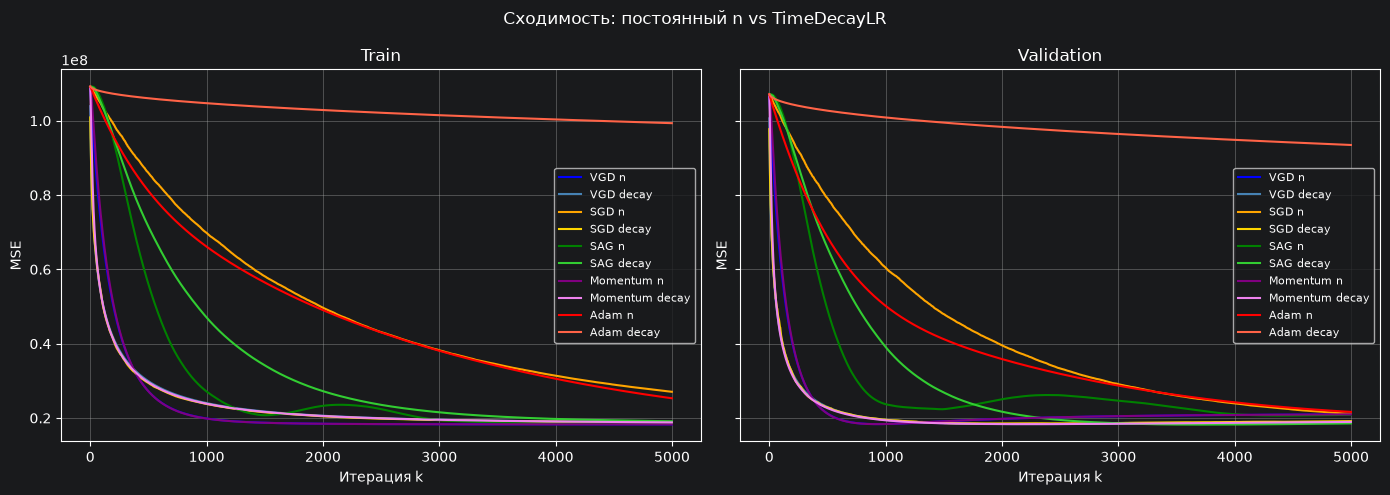

In [20]:
# 14. Итоговая таблица: метод, лучший шаг (n или формула n(lambda)), метрики, итерации
comparison = pd.DataFrame(sem_rows)
display(
    comparison.style.format({
        "Loss train": "{:.2f}",
        "Loss test": "{:.2f}",
        "R2 train": "{:.4f}",
        "R2 test": "{:.4f}",
    })
)

# Сравнение сходимости: слева train, справа val
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for name, pack, color in [
    ("VGD n", vgd_n, "blue"),
    ("VGD decay", vgd_d, "steelblue"),
    ("SGD n", sgd_n, "orange"),
    ("SGD decay", sgd_d, "gold"),
    ("SAG n", sag_n, "green"),
    ("SAG decay", sag_d, "limegreen"),
    ("Momentum n", mom_n, "purple"),
    ("Momentum decay", mom_d, "violet"),
    ("Adam n", adam_n, "red"),
    ("Adam decay", adam_d, "tomato"),
]:
    axes[0].plot(pack["hist_tr"], label=name, color=color)
    axes[1].plot(pack["hist_val"], label=name, color=color)
axes[0].set_title("Train")
axes[1].set_title("Validation")
for ax in axes:
    ax.set_xlabel("Итерация k")
    ax.set_ylabel("MSE")
    ax.grid(True)
    ax.legend(fontsize=8)
fig.suptitle("Сходимость: постоянный n vs TimeDecayLR")
plt.tight_layout()
plt.show()


15. Сделайте вывод о том, какой метод и шаг линейной регрессии самый лучший для данной выборки и ответьте на вопросы:

1) почему именно этот метод и этот шаг самый лучший (по каким данным из таблицы вы сделали такой вывод)

2) расскажите простыми словами суть R^2_train и R^2_test?

3) как R^2_train и R^2_test помогают сравнивать методы? почему оба эти значения надо вычислять для данного выбора?

15. Сделайте вывод о том, какой метод и шаг линейной регрессии самый лучший для данной выборки и ответьте на вопросы
лучший - SAG постоянным шагом n = 0.0001

1) почему именно этот метод и этот шаг самый лучший (по каким данным из таблицы вы сделали такой вывод)

По R2 тест и лосс тест - это объективные оценки модели на тестовой выборке. Тут р2 ближайшая к 1 а лосс наименьший

2) расскажите простыми словами суть R^2_train и R^2_test?

R² — доля разброса цены
- 1 — идеально попали в цену.
- 0 — не лучше, чем всегда предсказывать среднюю цену.
- меньше 0 — хуже константы.

трейн и тест - метрика соответтсвенно на этих выборках

3) как R^2_train и R^2_test помогают сравнивать методы? почему оба эти значения надо вычислять для данного выбора?

По ним можно оценить степень угадывания параметров моделью. Если смотреть только одно - нельзя понять состояние модели (недо/пере/обучилась)